# Przetwarzanie danych ustrukturyzowanych

Copyright © 2019-2026 [Anna Cena](http://www.cena.rexamine.com). All rights reserved. Do not redistribute. This notebook or any portion thereof may not be reproduced or used in any manner whatsoever without the express written permission of the author.

email: anna.cena@pw.edu.pl

## Przykład / wprowadzenie do projektu

In [1]:
# importujemy przydatne pakiety:

import pandas as pd
import numpy as np
import os, os.path
import glob

pd.set_option("display.notebook_repr_html", False) 

In [2]:
data_path = 'spotify_data/' # ścieżka dostępu do danych
                            # ścieżka względna: w aktualnym katalogu roboczym
                            # mamy podkatalog spotify_data, gdzie znajdują się
                            # pliki csv z danymi

pliki = os.listdir(data_path) # wykaz plików w danym katalog

In [3]:
pliki[:10] # wypiszemy kilka pierwszych nazw plików

['indian.csv',
 'cantopop.csv',
 'latino.csv',
 'funk.csv',
 'dancehall.csv',
 'groove.csv',
 'grindcore.csv',
 'songwriter.csv',
 'power-pop.csv',
 'dance.csv']

In [4]:
# Zobaczmy przykładowy plik z danymi

X = pd.read_csv(os.path.join( data_path, pliki[0] ))
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          1000 non-null   object 
 1   artists           1000 non-null   object 
 2   album_name        1000 non-null   object 
 3   track_name        1000 non-null   object 
 4   popularity        1000 non-null   int64  
 5   duration_ms       1000 non-null   int64  
 6   explicit          1000 non-null   bool   
 7   danceability      1000 non-null   float64
 8   energy            1000 non-null   float64
 9   key               1000 non-null   int64  
 10  loudness          1000 non-null   float64
 11  mode              1000 non-null   int64  
 12  speechiness       1000 non-null   float64
 13  acousticness      1000 non-null   float64
 14  instrumentalness  1000 non-null   float64
 15  liveness          1000 non-null   float64
 16  valence           1000 non-null   float64
 

In [5]:
X.head(2)

                 track_id                                   artists  \
0  0NLkVxf0PyxsXBG3EuZcJf                                 Anuv Jain   
1  6VBhH7CyP56BXjp8VsDFPZ  Pritam;Arijit Singh;Amitabh Bhattacharya   

                     album_name                    track_name  popularity  \
0                           Gul                           Gul          71   
1  Kesariya (From "Brahmastra")  Kesariya (From "Brahmastra")          88   

   duration_ms  explicit  danceability  energy  key  loudness  mode  \
0       217241     False         0.600   0.294    6   -12.301     1   
1       268164     False         0.577   0.574    0    -6.525     1   

   speechiness  acousticness  instrumentalness  liveness  valence   tempo  \
0       0.0292         0.871          0.000087     0.102    0.342  86.970   
1       0.0278         0.572          0.000000     0.100    0.436  94.009   

   time_signature track_genre  
0               4      indian  
1               4      indian  

In [6]:
X.shape # wymiar: 1000 wierszy (piosenek)
        #         20 kolumn  

(1000, 20)

In [7]:
X.artists.unique().shape # ilu mamy artystów w ramach tego gatunku

(549,)

Pytanie badawcze: jak wygląda rozkład liczby wykonawców w poszczególnych gatunkach muzycznych? 

Inaczej - ilu mamy unikatowych wykonawców w każdym gatunku? 

Inaczej - który gatunek przyciąga najwięcej atrystów?

In [8]:
import tqdm # pakiet pozwala na proste tworzenie progress bar

count = [] # tu zliczamy ilu mamy unikatowych artystów
genre = [] # tu zapamietujemy gatunek
for plik in tqdm.tqdm( pliki ):
    try:# sprawdzamy czy plik jest dobry
        # wczytujemy dane
        X = pd.read_csv( os.path.join(data_path, plik) )
        # zliczamy ilu mamy unikatowych artystów
        count.append( X.artists.unique().shape[0] )
        genre.append( plik )
    except:
        print(":(")
        print(plik)

 59%|█████████████████████████████████████████████████████████████████████▏                                               | 68/115 [00:00<00:00, 171.31it/s]

:(
README.md


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 115/115 [00:00<00:00, 167.23it/s]


In [9]:
wyniki = pd.DataFrame({
    "gatunek": genre,
    "liczba_artystow": count
})

In [10]:
wyniki.head() # ramka danych z liczbą wykonawców w każdym gatunku

         gatunek  liczba_artystow
0     indian.csv              549
1   cantopop.csv              253
2     latino.csv              403
3       funk.csv              529
4  dancehall.csv              519

In [11]:
# czyścimy kolumnę z nazwą gatunku
wyniki.gatunek = wyniki.gatunek.str.replace(".csv", "")

In [12]:
wyniki.head() # kilka pierwszych wierszy

     gatunek  liczba_artystow
0     indian              549
1   cantopop              253
2     latino              403
3       funk              529
4  dancehall              519

In [13]:
wyniki.shape # mamy 114 gatunków muzycznych

(114, 2)

In [14]:
# posortujemy ramkę danych tak by liczba artystów była 
# posortowana malejąco
wyniki.sort_values('liczba_artystow', ascending=False, inplace=True)

In [15]:
# Odpowiedź na pytanie:
# top 10 gatunków o największej liczbie artystów
wyniki.head(10)

               gatunek  liczba_artystow
14             dubstep              751
98          deep-house              727
70   progressive-house              694
105                dub              694
12            pop-film              662
80       drum-and-bass              619
39          electronic              612
29          show-tunes              605
111             trance              602
108          hardstyle              588

In [16]:
# 10 gatunków o najmniejszej liczbie artystów
wyniki.tail(10)

        gatunek  liczba_artystow
8     power-pop              188
36         kids              170
41      romance              163
83      iranian              163
60       grunge              154
25     children              149
6     grindcore              131
20  heavy-metal              107
10       j-idol               95
58   honky-tonk               81

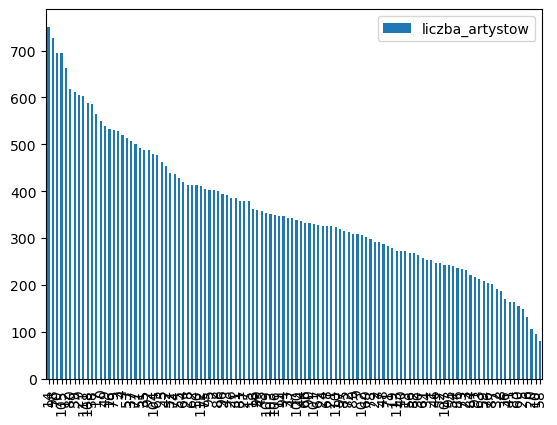

In [17]:
# Spróbujemy przedstawić dane graficznie
import matplotlib.pyplot as plt
# Wykres słupkowy - każy słupej odpowiada gatunkowi muzycznemu
# jego wysokość to liczba artystów tworzących ten gatunek
wyniki.plot(kind = 'bar')
plt.show() 
# wykres jest mało czytelny...
# spróbujmy go poprawić (więcej będziemy mówić o tym na wykładzie z grafiki)

In [18]:
# Poszerzymy zakres danych do wykresu

import tqdm # pakiet pozwala na proste tworzenie progress bar

count = [] # tu zliczamy ilu mamy unikatowych artystów
danceability = [] # tu będziemy zliczać średnią "taneczność" utworów w danym gatunku
genre = [] # tu zapamietujemy gatunek
for plik in tqdm.tqdm( pliki ):
    try:# sprawdzamy czy plik jest dobry
        # wczytujemy dane
        X = pd.read_csv( os.path.join(data_path, plik) )
        # zliczamy ilu mamy unikatowych artystów
        count.append( X.artists.unique().shape[0] )
        genre.append( plik )
        danceability.append( X.danceability.mean() )
    except:
        print(":(")
        print(plik)

 60%|██████████████████████████████████████████████████████████████████████▏                                              | 69/115 [00:00<00:00, 172.57it/s]

:(
README.md


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 115/115 [00:00<00:00, 167.63it/s]


In [19]:
wyniki = pd.DataFrame({
    "gatunek": genre,
    "liczba_artystow": count,
    "tanecznosc": danceability
})
wyniki.gatunek = wyniki.gatunek.str.replace(".csv", "")
wyniki.head()

     gatunek  liczba_artystow  tanecznosc
0     indian              549    0.592273
1   cantopop              253    0.547909
2     latino              403    0.757057
3       funk              529    0.678184
4  dancehall              519    0.734169

In [20]:
# top 10 gatunkow o najwiekszej sredniej "taneczności"
wyniki.sort_values('tanecznosc', ascending = False).head(10)

           gatunek  liczba_artystow  tanecznosc
36            kids              170    0.778906
94   chicago-house              346    0.766176
62       reggaeton              413    0.758521
2           latino              403    0.757057
88          reggae              401    0.745331
28         hip-hop              414    0.736154
4        dancehall              519    0.734169
77  minimal-techno              501    0.729395
32  detroit-techno              192    0.722568
45           latin              357    0.721902

In [21]:
# top 10 gatunkow o najmniejszej średniej "taneczności"
wyniki.sort_values('tanecznosc', ascending = True).head(10)

         gatunek  liczba_artystow  tanecznosc
112        sleep              411    0.167922
6      grindcore              131    0.271854
113  black-metal              273    0.296411
83       iranian              163    0.300686
92         opera              487    0.313563
87       new-age              202    0.348455
21       ambient              325    0.367867
54   death-metal              241    0.368411
74     classical              437    0.381923
46   world-music              246    0.414572

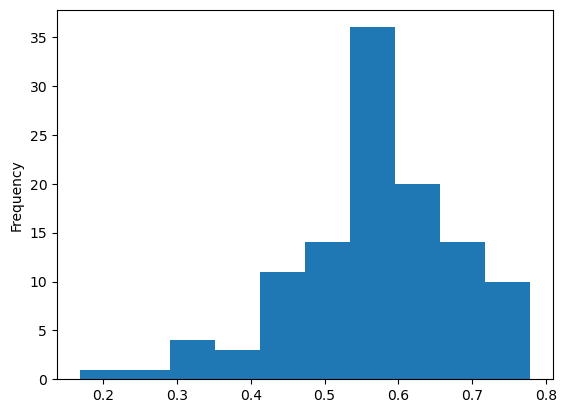

In [22]:
wyniki.tanecznosc.plot(kind = 'hist')
plt.show()
# rozkład gatunków gdy ocenimy je wzgledem średniej "taneczności" utworów
# widzimy, że większość gatunków ma średnią taneczność utworów wyższą niż 0.5

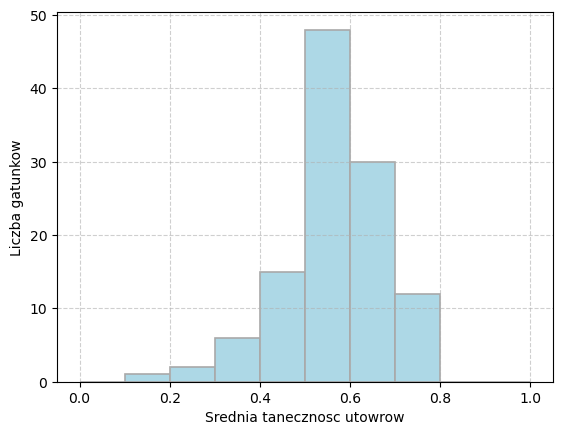

In [23]:
# Poprawimy wykres żeby był ładniejszy :)
wyniki.tanecznosc.plot(
    kind='hist',
    color='lightblue',     # kolor słupków
    edgecolor='darkgray',  # color obramowania słupków
    linewidth=1.2,         # grubość ramek słupków
    bins = np.linspace(0, 1, 11) # sami podamy przedziały taneczności
)

plt.grid(True, linestyle='--', alpha=0.6)  # dodajemy linie tzw. grid
plt.ylabel("Liczba gatunkow")
plt.xlabel("Srednia tanecznosc utowrow")
plt.show()

In [24]:
# teraz podzielimy gatunki ze względu na "taneczność" utworów w ramach tych gatunków

wyniki['grupy_tanecznosc'] = pd.cut(wyniki.tanecznosc, [0, 0.25, 0.5, 0.75, 1])

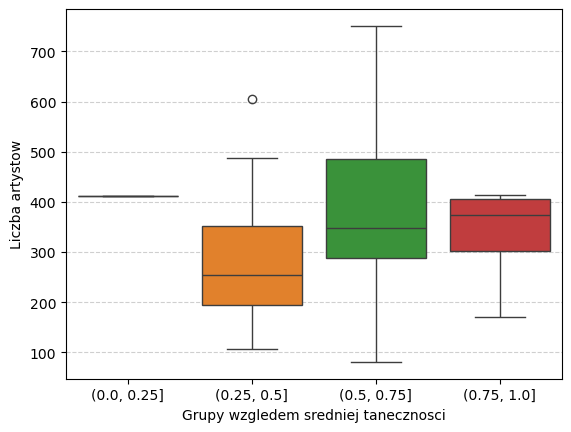

In [25]:
import seaborn as sns

# wykresy skrzynkowe (więcej o wykładzie na temat grafiki)
ax = sns.boxplot(
    data=wyniki,
    x='grupy_tanecznosc',
    y='liczba_artystow',
    hue='grupy_tanecznosc'     
)

ax.get_legend().remove()
plt.grid(axis='y', linestyle='--', alpha=0.6) 
plt.xlabel('Grupy wzgledem sredniej tanecznosci')
plt.ylabel('Liczba artystow')
plt.show()

In [26]:
# Sprawdzmy jaka jest korelacja (zob. zajecia laboratoryjne) 
# między tanecznoscią garunku a liczbą artystow

wyniki.loc[:, ['liczba_artystow', 'tanecznosc']].corr()
# Korelacja wynosi ok. 0.29 czyli nie jest zbyt wysoka; na podstawie danych
# nie widać silnej zależności między średnią tanecznością piosenek tworzonych
# w ramach gatunku muzycznego a liczbą artystów, którzy w nim tworzą

                 liczba_artystow  tanecznosc
liczba_artystow         1.000000    0.286189
tanecznosc              0.286189    1.000000